In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from tqdm import tqdm

from collections import Counter
from collections import defaultdict

from albumentations.pytorch import ToTensorV2
import albumentations as A

import cv2
import numpy as np
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd

import random
import os
from glob import glob

d:\LabsMIET\MLlab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 9999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
class_to_idx = { "Апельсин": 0,
                 "Бананы": 1,
                 "Груши": 2, 
                 "Кабачки": 3, 
                 "Капуста": 4, 
                 "Картофель": 5, 
                 "Киви": 6, 
                 "Лимон": 7, 
                 "Лук": 8, 
                 "Мандарины": 9, 
                 "Морковь": 10, 
                 "Огурцы": 11, 
                 "Томаты": 12, 
                 "Яблоки зелёные": 13, 
                 "Яблоки красные": 14 }

In [4]:
dataset_path = 'train/train'

writer = SummaryWriter("kirillLogs")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
class MyDataset(Dataset):
    def __init__(self, images_filepaths, name2label, transform=None):
        self.images_filepaths = images_filepaths
        self.transform = transform
        self.name2label = name2label

        self.labels = [
            name2label[os.path.normpath(p).split(os.sep)[-3]] 
            for p in images_filepaths
        ]
        
    def __len__(self):
        return len(self.images_filepaths)

    def __getitem__(self, idx):
        image_filepath = self.images_filepaths[idx]
        image = cv2.imdecode(np.fromfile(image_filepath, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.name2label[os.path.normpath(image_filepath).split(os.sep)[-3]]
        
        label = self.labels[idx]

        if self.transform is not None:
            image = self.transform(image=image)['image']
        return image, label

In [6]:
def collect_subclass_data(root_path):
    all_files = []
    # Это метка для StratifiedKFold (уникальная для каждого подкласса)
    subclass_labels_for_split = []

    # Счетчик для уникальных ID подклассов
    subclass_id_counter = 0

    # Проходим по Главным классам
    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)
        if not os.path.isdir(class_path):
            continue

        # Проходим по Подклассам
        for subclass_name in os.listdir(class_path):
            subclass_path = os.path.join(class_path, subclass_name)
            if not os.path.isdir(subclass_path):
                continue

            images = glob(os.path.join(subclass_path, '*.jpg')) + \
                     glob(os.path.join(subclass_path, '*.png')) + \
                     glob(os.path.join(subclass_path, '*.jpeg'))

            if len(images) == 0:
                continue

            # Добавляем пути
            all_files.extend(images)

            # Всем картинкам из этой папки присваиваем один и тот же ID подкласса
            # Например, все "Томаты/Черри" будут иметь ID 55
            # А "Томаты/Красные" будут иметь ID 56
            subclass_labels_for_split.extend([subclass_id_counter] * len(images))

            subclass_id_counter += 1

    return np.array(all_files), np.array(subclass_labels_for_split)

In [7]:
all_files, all_labels = collect_subclass_data(dataset_path)

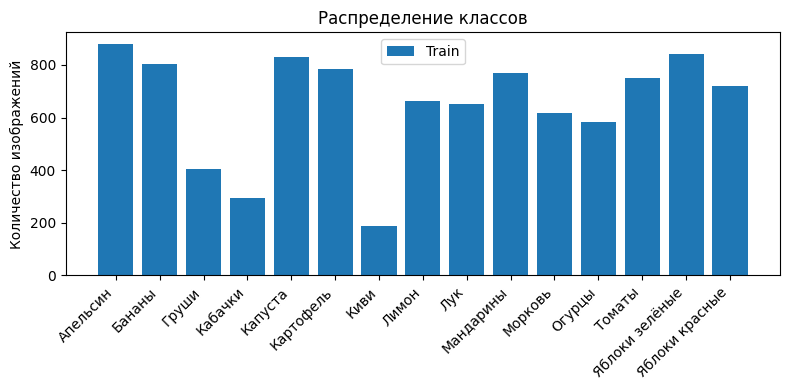

In [8]:
def count_classes(image_paths, class_to_idx):
    counts = Counter()
    for im_path in image_paths:
        class_name = os.path.normpath(im_path).split(os.sep)[-3]
        class_idx = class_to_idx[class_name]
        counts[class_idx] += 1
    return counts

data_counts = count_classes(all_files, class_to_idx)

idx2class = {v: k for k, v in class_to_idx.items()} # Конвертация class_to_idx -> idx2class

classes = list(idx2class.keys())
class_names = [idx2class[i] for i in classes]

data_values = [data_counts.get(i, 0) for i in classes]

x = np.arange(len(classes))

plt.figure(figsize=(8, 4))
plt.bar(x, data_values, label='Train')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Количество изображений')
plt.title('Распределение классов')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
IMG_SIZE = 224

train_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=1.0
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.5
    ),

    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.OneOf([
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        A.CLAHE(p=0.1),
    ], p=0.85),

    # Освещение и цвет
    A.OneOf([
        A.ColorJitter(brightness=0.1, contrast=0.0, saturation=0.0, hue=0.0),
        A.ColorJitter(brightness=0.0, contrast=0.1, saturation=0.0, hue=0.0),
        A.ColorJitter(brightness=0.0, contrast=0.0, saturation=0.1, hue=0.0),
    ], p=1),

    # Искажения
    A.OneOf([
        A.GaussianBlur(blur_limit=(3), sigma_limit=(0.1, 1.0), p=0.5),
        A.GaussNoise(std_range=(0.01, 0.02), noise_scale_factor=0.7, p=0.9),
    ], p=9),

    A.CoarseDropout(
        num_holes_range=(1, 16),
        hole_height_range=(0.02, 0.1),
        hole_width_range=(0.02, 0.1),
        fill=0,
        p=0.75
    ),

    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    A.ToTensorV2(),
])

val_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=1.0
    ),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])

C:\Users\Kirill\AppData\Local\Temp\ipykernel_30512\629686323.py:5: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
d:\LabsMIET\MLlab\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Kirill\AppData\Local\Temp\ipykernel_30512\629686323.py:13: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
C:\Users\Kirill\AppData\Local\Temp\ipykernel_30512\629686323.py:58: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


In [10]:
@torch.no_grad() # при вызове функции отключаем калькулятор градиентов
def evaluate(model, dataloader, loss_fn, device, desc="Val"):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    pbar = tqdm(dataloader, desc=desc, leave=False)
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        y_pred = logits.argmax(dim=1)
        total_correct += (y_pred == y_batch).sum().item()
        total_samples += batch_size

        avg_loss = total_loss / max(total_samples, 1)
        acc = total_correct / max(total_samples, 1)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.4f}")

    avg_loss = total_loss / max(total_samples, 1)
    accuracy = total_correct / max(total_samples, 1)
    return accuracy, avg_loss

In [11]:
from sched import scheduler


def train(model, loss_fn, optimizer, train_loader, val_loader, device, writer=None, n_epoch=3, lr_eta=1e-6):
    best_val_acc = 0.0
    best_val_loss = 100
    num_iter = 0
    counter_early_stop = 0

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epoch, eta_min=lr_eta) # планировщик скорости обучения
#     scheduler = torch.optim.lr_scheduler.OneCycleLR(
#         optimizer,
#         max_lr=5e-4,
#         total_steps=n_epoch * len(train_loader),   # можно указать total_steps вместо epochs + steps_per_epoch
#         pct_start=0.3,
#         anneal_strategy='cos',
#         div_factor=30.0,
#         final_div_factor=1e6,
#         three_phase=True,           # включает явный warmup → peak → cooldown
# )

    for epoch in range(1, n_epoch + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epoch}", leave=True)

        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            
            # накопим метрики для прогресс-бара
            batch_size = y_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            y_pred = logits.argmax(dim=1)
            total_correct += (y_pred == y_batch).sum().item()

            avg_loss = total_loss / max(total_samples, 1)
            acc = total_correct / max(total_samples, 1)

            # tqdm live-metrics
            pbar.set_postfix(train_loss=f"{avg_loss:.4f}", train_acc=f"{acc:.4f}")

            # логирование (по итерациям)
            num_iter += 1
            if writer is not None:
                writer.add_scalar("Loss/train", loss.item(), num_iter)
                writer.add_scalar("Accuracy/train", (y_pred == y_batch).float().mean().item(), num_iter)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        # Валидация (тоже с tqdm)
        val_acc, val_loss = evaluate(model, val_loader, loss_fn, device, desc=f"Val {epoch}/{n_epoch}")

        if writer is not None:
            writer.add_scalar("Loss/val", val_loss, num_iter)
            writer.add_scalar("Accuracy/val", val_acc, num_iter)
            writer.add_scalar(f"LR", current_lr, epoch)

        print(f"Epoch {epoch}/{n_epoch}: val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        # Проверка на лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            counter_early_stop = 0

            save_path = f"checkpoints/best_model.pth"
            torch.save(model.state_dict(), save_path)
            print(f"--- Эпоха {epoch}: Новая лучшая точность: {val_acc:.4f}! Модель сохранена. ---")
        elif (val_acc == best_val_acc) and (val_loss < best_val_loss):
            best_val_loss = val_loss
            counter_early_stop = 0

            save_path = f"checkpoints/best_model.pth"
            torch.save(model.state_dict(), save_path)
            print(f"--- Эпоха {epoch}: Новая лучшая точность: {val_acc:.4f}! Модель сохранена. ---")
        else: # Early stop
            counter_early_stop += 1
            if counter_early_stop > 5:
                print(f"Сработал Earle stop!")
                break

    # Загружаем лучший вес
    model.load_state_dict(torch.load(f"checkpoints/best_model.pth"))
    os.remove(f"checkpoints/best_model.pth")
    return model

In [12]:
@torch.no_grad()
def sklearn_report(model, dataloader, device, idx2class=None, digits=4):
    model.eval()

    y_true, y_pred = [], []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_pred.append(preds)
        y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # names for report
    if idx2class is None:
        target_names = None
        labels = None
    else:
        labels = sorted(idx2class.keys())
        target_names = [idx2class[i] for i in labels]

    rep = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=digits,
        zero_division=0
    )
    print(rep)

In [13]:
def class_weights(data_counts, num_classes, device):
    total_samples = sum(data_counts.values())
    weights = []

    for i in range(num_classes):
        count = data_counts[i]
        weight = total_samples / (num_classes * count)
        weights.append(weight)

    return torch.FloatTensor(weights).to(device)

class_weights = class_weights(data_counts, num_classes=15, device=device)
print("Веса классов:\n", class_weights)

Веса классов:
 tensor([0.7408, 0.8108, 1.6175, 2.2172, 0.7844, 0.8315, 3.4859, 0.9817, 1.0029,
        0.8455, 1.0565, 1.1181, 0.8703, 0.7760, 0.9041], device='cuda:0')


In [14]:
os.makedirs('checkpoints', exist_ok=True)
writer = SummaryWriter("logs")

n_fold = 5
ls = 0.1
skf = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=SEED)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=ls)

model_name = 'deit_tiny_distilled_patch16_224'

epoch = 25
b_size = 16
lr_ = 1e-4
lr_eta = 1e-6

In [15]:
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_files, all_labels)):
    print(f"\n--- Запуск фолда {fold_idx + 1}/{n_fold}  ---")

    # Выбираем файлы по индексам, которые дал SKF
    train_files = all_files[train_idx]
    val_files = all_files[val_idx]

    train_dataset = MyDataset(train_files, class_to_idx, transform=train_transforms)
    val_dataset   = MyDataset(val_files,   class_to_idx, transform=val_transforms)

    sample_weights = [class_weights[label].item() for label in train_dataset.labels]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_dataset),   
        replacement=True                  
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=b_size,
        sampler=sampler,           
        num_workers=0,
        pin_memory=True,
        persistent_workers=False,
        drop_last=True             
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model = timm.create_model(model_name, pretrained=True, num_classes=15)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_, weight_decay=0.01)

    model = train(model, loss_fn, optimizer, train_loader, val_loader, device, writer=None, n_epoch=epoch)

    sklearn_report(model, val_loader, device, idx2class={v: k for k, v in class_to_idx.items()})

    # Сохраняем модель текущего фолда
    save_path = f"checkpoints/{model_name}_{fold_idx+1}.pth"
    torch.save(model.state_dict(), save_path)

    # Очистка памяти GPU перед следующим фолдом
    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache()

d:\LabsMIET\MLlab\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



--- Запуск фолда 1/5  ---


Epoch 1/25: 100%|██████████| 488/488 [00:50<00:00,  9.70it/s, train_acc=0.7176, train_loss=1.1632]


Epoch 1/25: val_loss=1.0136  val_acc=0.8742
--- Эпоха 1: Новая лучшая точность: 0.8742! Модель сохранена. ---


Epoch 2/25: 100%|██████████| 488/488 [00:49<00:00,  9.91it/s, train_acc=0.8655, train_loss=0.8334]


...

Epoch 23/25: val_loss=0.8195  val_acc=0.9570


Epoch 24/25: 100%|██████████| 488/488 [00:51<00:00,  9.56it/s, train_acc=0.9927, train_loss=0.5628]


Epoch 24/25: val_loss=0.8154  val_acc=0.9570


Epoch 25/25: 100%|██████████| 488/488 [00:51<00:00,  9.54it/s, train_acc=0.9915, train_loss=0.5608]


Epoch 25/25: val_loss=0.8154  val_acc=0.9565
                precision    recall  f1-score   support

      Апельсин     0.9659    0.9659    0.9659       176
        Бананы     0.9873    0.9750    0.9811       160
         Груши     0.9268    0.9383    0.9325        81
       Кабачки     0.9831    0.9831    0.9831        59
       Капуста     0.9939    0.9819    0.9879       166
     Картофель     0.9603    0.9236    0.9416       157
          Киви     0.6875    0.8919    0.7765        37
         Лимон     0.9635    0.9925    0.9778       133
           Лук     0.9528    0.9308    0.9416       130
     Мандарины     0.9308    0.9610    0.9457       154
       Морковь     0.9667    0.9355    0.9508       124
        Огурцы     0.9831    1.0000    0.9915       116
        Томаты     0.9408    0.9533    0.9470       150
Яблоки зелёные     0.9763    0.9821    0.9792       168
Яблоки красные     0.9630    0.9028    0.9319       144

      accuracy                         0.9575      1955
 

In [16]:
ac1 = 0.9657
ac2 = 0.9611 
ac3 = 0.9581
ac4 = 0.9570
ac5 = 0.9575

sum = ac1 + ac2 + ac3 + ac4 + ac5
avg = sum / 5

In [17]:
submission_path = "sample_submission.csv"
output_path = "submissionDeiT.csv"
test_images_dir = "test_images/test_images"
# Веса для моделей
model_weights = [ac1/sum, ac2/sum]
weights_tensor = torch.tensor(model_weights, device=device).view(1, -1, 1)
submission = pd.read_csv(submission_path)
final_predictions = []

In [18]:
models = []
# Загрузка моделей
for n in range(2):
    path = f"checkpoints/{model_name}_{n+1}.pth"
    model_i = timm.create_model(model_name, pretrained=False, num_classes=15)
    model_i.load_state_dict(torch.load(path, map_location=device))
    model_i.to(device)
    model_i.eval()
    models.append(model_i)

In [19]:
with torch.no_grad():
    for image_id in tqdm(submission["image_id"], desc="Predicting"):

        image_path = os.path.join(test_images_dir, image_id)
        image = cv2.imdecode(np.fromfile(image_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if val_transforms is not None:
            image = val_transforms(image=image)["image"]

        img = image.to(device)

        # TTA (Test Time Augmentation)
        img_orig = img
        img_h = torch.flip(img, [2])      # Горизонтально
        img_v = torch.flip(img, [1])      # Вертикально
        img_hv = torch.flip(img, [1, 2])  # И так и так

        # Собираем в батч: [4, 3, 224, 224]
        batch_tta = torch.stack([img_orig, img_h, img_v, img_hv])

        all_models_probs = []

        for m in models:
            logits = m(batch_tta)
            # [4, 15]
            probs_tta = F.softmax(logits, dim=1)
            # [15]
            avg_prob_model = probs_tta.mean(dim=0)
            all_models_probs.append(avg_prob_model)

        # [N_MODEL, 15]
        stacked_probs = torch.stack(all_models_probs)

        weighted_probs = torch.zeros_like(stacked_probs[0]) # [15]

        for i, prob in enumerate(all_models_probs):
            weighted_probs += prob * model_weights[i]
        # Финальный выбор класса
        pred_idx = weighted_probs.argmax().item()
        final_predictions.append(pred_idx)

# Сохранение
submission["label"] = final_predictions
submission.to_csv(output_path, index=False)
submission.head()

Predicting: 100%|██████████| 2503/2503 [00:35<00:00, 70.99it/s]


,image_id,label
0,fd343552326b42c5a62c192f32549dc7.jpg,2
1,445ca69812cf44f581cc8a89223af277.jpg,7
2,570626ce4d8f41edb8088f49d40a2195.jpg,7
3,02d4acba92f343d798adcb4958fe684b.jpg,11
4,2d4b8e8f38534a39b0d02c440e917b83.jpg,14
